# Find optimal parameters for UMAP

In [1]:
### Imports
from rail.core.data import DataStore
from rail.core.stage import RailStage
from rail.core.data import PqHandle

import numpy as np
import h5py
import pandas as pd
import tables_io

# from UMAPEstimator import UMAPEstimator

from rail.evaluation.dist_to_point_evaluator import DistToPointEvaluator
import optuna

# Specify paths and parameters

In [3]:
### Specify path to noisy catalog
noisy_catalog_path = "/pscratch/sd/s/sajkov/data/integrated_catalog_23apr26_noised_19Jun26.pq"

### Specify path to output photometry
import time
date = time.strftime('%d%b%y', time.localtime())
photoz_path = noisy_catalog_path.split('.pq')[0] + f'_UMAPphotoz_{date}.pq'

# Split data into training and validation

In [4]:
training_fraction = 0.8


metric            = "manhattan_weighted_linear"
seed              = 42

In [5]:
rng = np.random.default_rng(seed = seed)

In [6]:
data = tables_io.read(noisy_catalog_path)

column_list None


In [49]:
data_cut_amount = 100000
i_band_cut = 27.5
magnitude_cut_idx = np.where(data["LSST_i"] < i_band_cut)[0]
data_magnitude_rand_idx = rng.choice(magnitude_cut, size = int(1.25 * data_cut_amount), replace = False)

In [50]:
training_indices = data_magnitude_rand_idx[:data_cut_amount]
testing_indices = data_magnitude_rand_idx[data_cut_amount:]

In [51]:
np.isin(training_indices, testing_indices).sum()

np.int64(0)

In [52]:
np.isin(testing_indices, training_indices).sum()

np.int64(0)

In [ ]:
import matplotlib.pyplot as plt

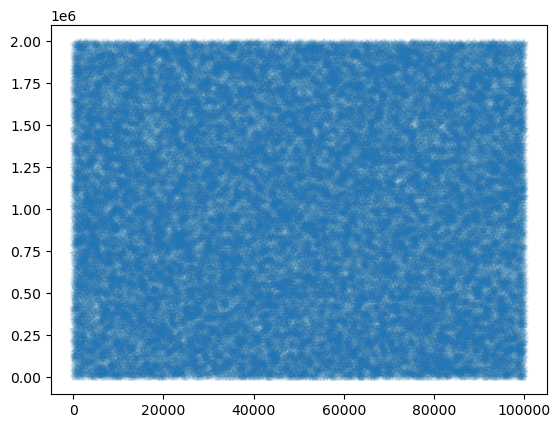

In [40]:
fig = plt.figure()
ax = fig.add_subplot()
ax.plot(training_indices, marker = '*', linestyle = 'none', alpha = 0.05)

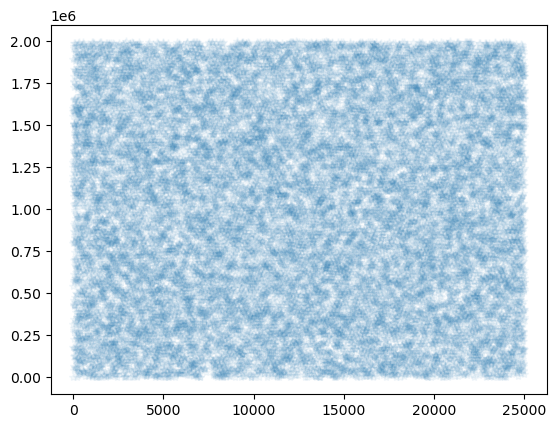

In [41]:
fig = plt.figure()
ax = fig.add_subplot()
ax.plot(testing_indices, marker = '*', linestyle = 'none', alpha = 0.05)

In [ ]:
training_indices = rng.choice

In [5]:
data = tables_io.read(noisy_catalog_path)

data_cut = int(1e3)
# data_cut = -1
data = data[:data_cut]

training_indices = np.zeros(len(data), dtype = bool)
training_indices[np.random.choice(len(data), size = int(training_fraction * len(data)),
                 replace = False)] = True

bands = [key for key in data.keys() if (not key.endswith('_err')) & (key != 'Roman_F146')]
error_bands = [key for key in data.keys() if key.endswith('_err')]

validation_data = data[~training_indices]
training_data   = data[training_indices]

column_list None


In [6]:
photometry_bands = [key for key in training_data.keys()\
                        if (not key.endswith('_err')) and (key != 'Roman_F146')]
phot_error_bands = [f"{key}_err" for key in photometry_bands]

In [ ]:
redshift_filepath = "/pscratch/sd/s/sajkov/data/mock_catalog_Ch1_26.h5"
redshift          = h5py.File(redshift_filepath)['sps_parameters'][:, -1]

training_redshift   = redshift[:data_cut][training_indices]
validation_redshift = redshift[:data_cut][~training_indices]

# Instantiate and run RAIL stage

In [9]:
RailStage.data_store = DataStore()

stage = UMAPEstimator.make_stage(
    name = "UMAP_informer",
    
    ambient_metric_umap = metric,
    
    seed = seed
)

stage.set_data("training_photometry", data = training_data[photometry_bands])
stage.set_data("training_phot_error", data = training_data[phot_error_bands])
stage.set_data("training_redshift",   data = training_redshift)

2026-06-26 10:35:38 [info     ] Inserting handle into data store.  training_photometry: None, UMAP_informer
2026-06-26 10:35:38 [info     ] Inserting handle into data store.  training_phot_error: None, UMAP_informer
2026-06-26 10:35:38 [info     ] Inserting handle into data store.  training_redshift: None, UMAP_informer


array([0.1092879 , 0.09602419, 0.17016256, 0.13377383, 0.12323937,
       0.13383639, 0.15923409, 0.1603817 , 0.11161227, 0.17651452,
       0.08270884, 0.21383935, 0.1655905 , 0.10060135, 0.13063174,
       0.13753265, 0.07175412, 0.10240334, 0.16094378, 0.2408389 ,
       0.17588614, 0.13729158, 0.13942134, 0.19034447, 0.1407525 ,
       0.09347411, 0.07178996, 0.15648504, 0.14547403, 0.12437538,
       0.16284315, 0.11270642, 0.12642746, 0.12863824, 0.11174067,
       0.08650419, 0.17662033, 0.1303938 , 0.01875363, 0.1531041 ,
       0.18075211, 0.11936077, 0.07814855, 0.11836035, 0.08076877,
       0.07449096, 0.11124317, 0.13655037, 0.11322581, 0.12435413,
       0.15081182, 0.14417288, 0.23995706, 0.15239383, 0.13749155,
       0.19013022, 0.15098381, 0.14701848, 0.15634614, 0.11501562,
       0.12695222, 0.10680281, 0.11829594, 0.1258662 , 0.01528157,
       0.04257841, 0.1827475 , 0.23427503, 0.16086806, 0.12248144,
       0.08702984, 0.10467938, 0.12034947, 0.13655044, 0.15871

# Inform the estimator

In [1]:
stage.UMAP_informer()

NameError: name 'stage' is not defined

# Estimate redshifts

In [11]:
stage.set_data("estimation_photometry", data = validation_data[photometry_bands])
stage.set_data("estimation_phot_error", data = validation_data[phot_error_bands])
stage.UMAP_estimator()

2026-06-26 10:35:58 [info     ] Inserting handle into data store.  estimation_photometry: None, UMAP_informer
2026-06-26 10:35:58 [info     ] Inserting handle into data store.  estimation_phot_error: None, UMAP_informer
2026-06-26 10:36:06 [info     ] Inserting handle into data store.  estimated_embedding_UMAP_informer: inprogress_estimated_embedding_UMAP_informer.pq, UMAP_informer
2026-06-26 10:36:06 [info     ] Inserting handle into data store.  estimated_photoz_medians_UMAP_informer: inprogress_estimated_photoz_medians_UMAP_informer.pq, UMAP_informer
2026-06-26 10:36:06 [info     ] Inserting handle into data store.  estimated_photoz_pdfs_UMAP_informer: inprogress_estimated_photoz_pdfs_UMAP_informer.hdf5, UMAP_informer


In [12]:
estimated_photoz_pdfs = stage.get_handle('estimated_photoz_pdfs').data
estimated_photoz_medians = stage.get_handle('estimated_photoz_medians').data

# Evaluate

# Plot redshifts

In [ ]:
import matplotlib.pyplot as plt
plt.style.use('/Users/leo/Projects/LBG_cosmology/code/umap_nz_cal.mplstyle')

In [ ]:
fig = plt.figure()
ax = fig.add_subplot()
ax.set_xlim(0, .5)

index = 0

estimated_photoz_pdfs.plot(index, axes = ax)
ax.axvline(estimated_photoz_medians.values[index])

ax.set_xlabel('Redshift')
ax.set_ylabel('Density')

In [ ]:
evaluator = DistToPointEvaluator.make_stage(
    name = "DistToPointEvaluator",
    metrics = ["cdeloss"],
    reference_dictionary_key = "true_z",
    hdf5_groupname = "",
    metric_integration_limits = [0, 3],
    dx = 0.001,
    output_mode = "return"
)

In [ ]:
evaluation = evaluator.evaluate(estimated_photoz_pdfs,
                                pd.DataFrame({"true_z": validation_redshift}))

In [13]:
### Hedging: load data
### Hedging: 

def objective(trial):
    
    RailStage.data_store = DataStore()
    
    n_neighbors_umap = trial.suggest_int("n_neighbors_umap", 10, 200, step  = 5)
    min_dist         = trial.suggest_float("min_dist",       0,  1,   step  = 0.05)
    
    n_neighbors_knn = trial.suggest_int("n_neighbors_knn",  5, 200, step  = 5)
    metric_p_knn    = trial.suggest_int("n_neighbors_umap", 1, 5,   step  = 1)
    

    estimator = UMAPEstimator.make_stage(
        name = "UMAP_estimator",
        
        ambient_metric_umap = metric,
        
        n_neighbors_umap = n_neighbors_umap,
        min_dist         = min_dist,
        
        n_neighbors_knn = n_neighbors_knn,
        metric_p_knn    = metric_p_knn,
        
        seed = seed
    )

    estimator.set_data("training_photometry", data = training_data[photometry_bands])
    estimator.set_data("training_phot_error", data = training_data[phot_error_bands])
    estimator.set_data("training_redshift",   data = training_redshift)
    
    estimator.UMAP_informer()
    
    estimator.set_data("estimation_photometry", data = validation_data[photometry_bands])
    estimator.set_data("estimation_phot_error", data = validation_data[phot_error_bands])
    estimator.UMAP_estimator()
    
    evaluator = DistToPointEvaluator.make_stage(
        name = "DistToPointEvaluator",
        metrics = ["cdeloss"],
        reference_dictionary_key = "true_z",
        hdf5_groupname = "",
        metric_integration_limits = [0, 3],
        dx = 0.001,
        output_mode = "return"
    )
    
    evaluation = evaluator.evaluate(estimator.get_handle('estimated_photoz_pdfs').data,
                                     pd.DataFrame({"true_z": validation_redshift}))
    
    cdeloss = evaluation["summary"].read()['cdeloss'][0]
    
    return cdeloss

In [14]:
study = optuna.create_study()

[I 2026-06-26 10:36:24,793] A new study created in memory with name: no-name-6dd4dd61-183b-4b66-9058-c84748a3015c


In [15]:
study.optimize(objective, n_trials = 10)

2026-06-26 10:36:26 [info     ] Inserting handle into data store.  training_photometry: None, UMAP_estimator
2026-06-26 10:36:26 [info     ] Inserting handle into data store.  training_phot_error: None, UMAP_estimator
2026-06-26 10:36:26 [info     ] Inserting handle into data store.  training_redshift: None, UMAP_estimator


/global/homes/s/sajkov/.conda/envs/rail/lib/python3.14/site-packages/optuna/trial/_trial.py:692: RuntimeWarning: Inconsistent parameter values for distribution with name "n_neighbors_umap"! This might be a configuration mistake. Optuna allows to call the same distribution with the same name more than once in a trial. When the parameter values are inconsistent optuna only uses the values of the first call and ignores all following. Using these values: {'log': False, 'step': 5, 'low': 10, 'high': 200}
  optuna_warn(
/global/homes/s/sajkov/.conda/envs/rail/lib/python3.14/site-packages/umap/umap_.py:1857: UserWarning: custom distance metric does not return gradient; inverse_transform will be unavailable. To enable using inverse_transform method, define a distance function that returns a tuple of (distance [float], gradient [np.array])
  warn(
/global/homes/s/sajkov/.conda/envs/rail/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting rando

2026-06-26 10:36:28 [info     ] Inserting handle into data store.  informed_reducer_UMAP_estimator: inprogress_informed_reducer_UMAP_estimator.pkl, UMAP_estimator
2026-06-26 10:36:28 [info     ] Inserting handle into data store.  informed_embedding_UMAP_estimator: inprogress_informed_embedding_UMAP_estimator.pq, UMAP_estimator
2026-06-26 10:36:28 [info     ] Inserting handle into data store.  informed_kNN_regressor_UMAP_estimator: inprogress_informed_kNN_regressor_UMAP_estimator.pkl, UMAP_estimator
2026-06-26 10:36:28 [info     ] Inserting handle into data store.  estimation_photometry: None, UMAP_estimator
2026-06-26 10:36:28 [info     ] Inserting handle into data store.  estimation_phot_error: None, UMAP_estimator
2026-06-26 10:37:05 [info     ] Inserting handle into data store.  estimated_embedding_UMAP_estimator: inprogress_estimated_embedding_UMAP_estimator.pq, UMAP_estimator
2026-06-26 10:37:05 [info     ] Inserting handle into data store.  estimated_photoz_medians_UMAP_estimator

[I 2026-06-26 10:37:05,462] Trial 0 finished with value: -6.084098725976653 and parameters: {'n_neighbors_umap': 25, 'min_dist': 0.7000000000000001, 'n_neighbors_knn': 180}. Best is trial 0 with value: -6.084098725976653.


2026-06-26 10:37:05 [info     ] Inserting handle into data store.  training_photometry: None, UMAP_estimator
2026-06-26 10:37:05 [info     ] Inserting handle into data store.  training_phot_error: None, UMAP_estimator
2026-06-26 10:37:05 [info     ] Inserting handle into data store.  training_redshift: None, UMAP_estimator


/global/homes/s/sajkov/.conda/envs/rail/lib/python3.14/site-packages/optuna/trial/_trial.py:692: RuntimeWarning: Inconsistent parameter values for distribution with name "n_neighbors_umap"! This might be a configuration mistake. Optuna allows to call the same distribution with the same name more than once in a trial. When the parameter values are inconsistent optuna only uses the values of the first call and ignores all following. Using these values: {'log': False, 'step': 5, 'low': 10, 'high': 200}
  optuna_warn(
/global/homes/s/sajkov/.conda/envs/rail/lib/python3.14/site-packages/umap/umap_.py:1857: UserWarning: custom distance metric does not return gradient; inverse_transform will be unavailable. To enable using inverse_transform method, define a distance function that returns a tuple of (distance [float], gradient [np.array])
  warn(
/global/homes/s/sajkov/.conda/envs/rail/lib/python3.14/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting rando

2026-06-26 10:37:07 [info     ] Inserting handle into data store.  informed_reducer_UMAP_estimator: inprogress_informed_reducer_UMAP_estimator.pkl, UMAP_estimator
2026-06-26 10:37:07 [info     ] Inserting handle into data store.  informed_embedding_UMAP_estimator: inprogress_informed_embedding_UMAP_estimator.pq, UMAP_estimator
2026-06-26 10:37:07 [info     ] Inserting handle into data store.  informed_kNN_regressor_UMAP_estimator: inprogress_informed_kNN_regressor_UMAP_estimator.pkl, UMAP_estimator
2026-06-26 10:37:07 [info     ] Inserting handle into data store.  estimation_photometry: None, UMAP_estimator
2026-06-26 10:37:07 [info     ] Inserting handle into data store.  estimation_phot_error: None, UMAP_estimator
2026-06-26 10:37:32 [info     ] Inserting handle into data store.  estimated_embedding_UMAP_estimator: inprogress_estimated_embedding_UMAP_estimator.pq, UMAP_estimator
2026-06-26 10:37:32 [info     ] Inserting handle into data store.  estimated_photoz_medians_UMAP_estimator

[W 2026-06-26 10:37:32,932] Trial 1 failed with parameters: {'n_neighbors_umap': 60, 'min_dist': 0.45, 'n_neighbors_knn': 105} because of the following error: OSError('Unable to synchronously create file (unable to truncate a file which is already open)').
Traceback (most recent call last):
  File "/global/homes/s/sajkov/.conda/envs/rail/lib/python3.14/site-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
  File "/tmp/ipykernel_237915/2019679359.py", line 49, in objective
    evaluation = evaluator.evaluate(estimator.get_handle('estimated_photoz_pdfs').data,
                                     pd.DataFrame({"true_z": validation_redshift}))
  File "/global/homes/s/sajkov/.conda/envs/rail/lib/python3.14/site-packages/rail/evaluation/evaluator.py", line 126, in evaluate
    self.run()
    ~~~~~~~~^^
  File "/global/homes/s/sajkov/.conda/envs/rail/lib/python3.14/site-packages/rail/evaluation/evaluator.py", line 154, in run
    self._process_ch

OSError: Unable to synchronously create file (unable to truncate a file which is already open)

In [ ]:
fig = plt.figure()
ax = fig.add_subplot()


ax.hexbin(validation_redshift, estimated_photoz_medians,
          mincnt = 1)
ax.axline((0, 0), slope = 1, color = 'red')

In [ ]:
def sigma_NMAD(estimated_z, true_z):
    
    delta_z = estimated_z - true_z
    
    return 1.4826 * np.median(np.abs(delta_z/(1 + true_z) - ))

In [ ]:
fig = plt.figure()
ax = fig.add_subplot()


ax.hexbin(validation_redshift, estimated_photoz_medians,
          mincnt = 1)
ax.axline((0, 0), slope = 1, color = 'red')

In [ ]:
# Save otputs